In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# CatBoost

In [2]:
# import geopandas as gpd

# blocks = gpd.read_file("../data/blocks_clean.geojson")
# blocks.head()

In [3]:
blocks = gpd.read_parquet('../data/traning_data/blocks_with_land_value_class.parquet')
blocks["land_use"] = blocks["land_use"].replace(
    [None, "None", "none", "NaN", "nan", "NULL", "null", ""],
    pd.NA
)
blocks = blocks[blocks["land_use"].notna()].copy()


blocks.head()

,geometry,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,...,area_accessibility,land_value_per_sqm,log_land_value,log_land_value_per_sqm,land_value_class_soft_0,land_value_class_soft_1,land_value_class_soft_2,land_value_class_soft_3,land_value_class_pred,land_value_class_soft_expected
0,"POLYGON ((352083.617 6633950.146, 352240.448 6...",0.099000,0.0,0.079912,0.000000,0.401072,0.0,0.417018,AGRICULTURE,0.417018,...,113.847998,942.386203,18.676889,6.849476,0.216733,0.474449,0.228485,0.080333,1,1.172418
1,"POLYGON ((346700.642 6618453.176, 346681.107 6...",1.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,RESIDENTIAL,1.000000,...,145.884534,1952.414484,19.040968,7.577334,0.012898,0.098665,0.817926,0.070511,2,1.946050
2,"POLYGON ((347043.363 6618261.219, 347042.608 6...",0.729125,0.0,0.270875,0.000000,0.000000,0.0,0.000000,RESIDENTIAL,0.729125,...,148.543184,1507.223306,19.061421,7.318688,0.014049,0.108015,0.819304,0.058632,2,1.922518
3,"POLYGON ((354879.039 6618859.116, 354845.405 6...",0.454375,0.0,0.000000,0.000000,0.144935,0.0,0.399984,RESIDENTIAL,0.454375,...,132.691062,2197.747147,19.737919,7.695643,0.008106,0.152586,0.646817,0.192490,2,2.023691
4,"POLYGON ((347215.933 6646341.789, 347245.429 6...",0.108707,0.0,0.000000,0.767131,0.057528,0.0,0.000000,INDUSTRIAL,0.767131,...,99.160727,8603.688296,17.843517,9.060062,0.604409,0.362198,0.031458,0.001936,0,0.430922


In [4]:
blocks_with_large_errors = gpd.read_file("../data/traning_data/blocks_with_large_errors.geojson")
blocks_with_error_over_60pct = gpd.read_file("../data/traning_data/blocks_with_error_over_60pct.geojson")
blocks_with_error_over_60pct2 = gpd.read_file("../data/traning_data/blocks_with_error_over_60pct2.geojson")
blocks_with_error_over_60pct3 = gpd.read_file("../data/traning_data/blocks_with_error_over_60pct3.geojson")
blocks_with_error_over_60pct3.head()   

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,n_neighbors_300,n_neighbors_500,n_neighbors_1000,n_neighbors_2000,n_neighbors_3000,pred_raw,land_value_pred,land_value_true,error_pct,geometry
0,0.108342,0.000000,0.891658,0.0,0.000000,0.0,0.0,RECREATION,0.891658,0.000000,...,5,14,60,205,447,5.678058e+07,5.678058e+07,1.786907e+07,217.758932,"POLYGON ((351428.245 6647300.266, 351440.055 6..."
1,0.024715,0.072627,0.489266,0.0,0.413393,0.0,0.0,RECREATION,0.489266,161.467098,...,10,21,74,248,427,6.659308e+06,6.659308e+06,2.074318e+07,67.896405,"POLYGON ((348997.996 6646368.274, 348999.869 6..."
2,0.226151,0.590566,0.132126,0.0,0.051156,0.0,0.0,BUSINESS,0.590566,32311.556107,...,4,10,43,181,434,5.592216e+08,5.592216e+08,3.421804e+08,63.428892,"POLYGON ((351482.192 6648261.957, 351499.765 6..."
3,0.999419,0.000581,0.000000,0.0,0.000000,0.0,0.0,RESIDENTIAL,0.999419,8227.586617,...,3,9,33,82,185,2.868954e+08,2.868954e+08,1.712276e+08,67.552047,"POLYGON ((347126.83 6643214.39, 347135.632 664..."
4,0.763586,0.000000,0.000000,0.0,0.236414,0.0,0.0,RESIDENTIAL,0.763586,4099.369141,...,4,15,52,154,291,1.421954e+08,1.421954e+08,8.546343e+07,66.381611,"POLYGON ((353573.678 6646818.066, 353573.235 6..."


In [5]:
# старт
blocks_clean = blocks.copy()

# 1) удалить blocks_with_large_errors
tmp = blocks_with_large_errors
if blocks_clean.crs != tmp.crs:
    tmp = tmp.to_crs(blocks_clean.crs)
bad_geom = set(tmp.geometry.to_wkb())
blocks_clean = blocks_clean.loc[~blocks_clean.geometry.to_wkb().isin(bad_geom)].copy()

# 2) удалить blocks_with_error_over_60pct
tmp = blocks_with_error_over_60pct
if blocks_clean.crs != tmp.crs:
    tmp = tmp.to_crs(blocks_clean.crs)
bad_geom = set(tmp.geometry.to_wkb())
blocks_clean = blocks_clean.loc[~blocks_clean.geometry.to_wkb().isin(bad_geom)].copy()

# # 3) удалить blocks_with_error_over_60pct2
tmp = blocks_with_error_over_60pct2
if blocks_clean.crs != tmp.crs:
    tmp = tmp.to_crs(blocks_clean.crs)
bad_geom = set(tmp.geometry.to_wkb())
blocks_clean = blocks_clean.loc[~blocks_clean.geometry.to_wkb().isin(bad_geom)].copy()

# # 4) удалить blocks_with_error_over_60pct3
# tmp = blocks_with_error_over_60pct3
# if blocks_clean.crs != tmp.crs:
#     tmp = tmp.to_crs(blocks_clean.crs)
# bad_geom = set(tmp.geometry.to_wkb())
# blocks_clean = blocks_clean.loc[~blocks_clean.geometry.to_wkb().isin(bad_geom)].copy()

blocks_clean.head()



,geometry,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,...,area_accessibility,land_value_per_sqm,log_land_value,log_land_value_per_sqm,land_value_class_soft_0,land_value_class_soft_1,land_value_class_soft_2,land_value_class_soft_3,land_value_class_pred,land_value_class_soft_expected
0,"POLYGON ((352083.617 6633950.146, 352240.448 6...",0.099000,0.0,0.079912,0.000000,0.401072,0.0,0.417018,AGRICULTURE,0.417018,...,113.847998,942.386203,18.676889,6.849476,0.216733,0.474449,0.228485,0.080333,1,1.172418
1,"POLYGON ((346700.642 6618453.176, 346681.107 6...",1.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,RESIDENTIAL,1.000000,...,145.884534,1952.414484,19.040968,7.577334,0.012898,0.098665,0.817926,0.070511,2,1.946050
2,"POLYGON ((347043.363 6618261.219, 347042.608 6...",0.729125,0.0,0.270875,0.000000,0.000000,0.0,0.000000,RESIDENTIAL,0.729125,...,148.543184,1507.223306,19.061421,7.318688,0.014049,0.108015,0.819304,0.058632,2,1.922518
3,"POLYGON ((354879.039 6618859.116, 354845.405 6...",0.454375,0.0,0.000000,0.000000,0.144935,0.0,0.399984,RESIDENTIAL,0.454375,...,132.691062,2197.747147,19.737919,7.695643,0.008106,0.152586,0.646817,0.192490,2,2.023691
4,"POLYGON ((347215.933 6646341.789, 347245.429 6...",0.108707,0.0,0.000000,0.767131,0.057528,0.0,0.000000,INDUSTRIAL,0.767131,...,99.160727,8603.688296,17.843517,9.060062,0.604409,0.362198,0.031458,0.001936,0,0.430922


In [6]:
# blocks_clean.to_parquet('../data/traning_data/blocks_clean_for_model_training.parquet', index=False)

In [7]:
# import matplotlib.pyplot as plt

# fig, ax = plt.subplots(figsize=(15, 15))

# # Все кварталы серым фоном
# blocks.plot(ax=ax, color="lightgray", edgecolor="white", linewidth=0.2)

# # Отфильтрованные поверх с раскраской по land_value_per_sqm
# blocks_clean.plot(
#     ax=ax,
#     column="land_value",
#     cmap="viridis",
#     legend=True,
#     edgecolor="black",
#     linewidth=0.2
# )

# ax.axis("off")
# plt.show()

In [8]:
import pandas as pd

col = "land_use"

# Кол-во по land_use в blocks
cnt_blocks = (
    blocks[col]
    .value_counts(dropna=False)
    .rename("count_blocks")
)

# Кол-во по land_use в blocks_clean
cnt_blocks_clean = (
    blocks_clean[col]
    .value_counts(dropna=False)
    .rename("count_blocks_clean")
)

# Объединяем в одну таблицу
land_use_counts = (
    pd.concat([cnt_blocks, cnt_blocks_clean], axis=1)
    .fillna(0)
    .astype(int)
    .reset_index()
    .rename(columns={"index": col})
    .sort_values(col, na_position="last")
)

display(land_use_counts)


,land_use,count_blocks,count_blocks_clean
5,AGRICULTURE,140,115
4,BUSINESS,309,251
3,INDUSTRIAL,497,427
1,RECREATION,1611,972
0,RESIDENTIAL,4835,4018
6,SPECIAL,124,99
2,TRANSPORT,1027,746


In [9]:
# import osmnx as ox
# import geopandas as gpd

# # 1) Граница Санкт-Петербурга
# city = ox.geocode_to_gdf("Saint Petersburg, Russia")
# city_polygon = city.geometry.iloc[0]

# # 2) Загружаем административные границы уровня 5
# tags = {
#     "boundary": "administrative",
#     "admin_level": "5",
# }

# districts = ox.features_from_polygon(city_polygon, tags=tags).reset_index()

# # 3) Оставляем только полигональные геометрии
# districts = districts[districts.geometry.geom_type.isin(["Polygon", "MultiPolygon"])].copy()

# # 4) Полезные поля
# keep_cols = [
#     c for c in [
#         "name",
#         "name:ru",
#         "official_name",
#         "boundary",
#         "admin_level",
#         "wikidata",
#         "geometry",
#     ]
#     if c in districts.columns
# ]

# districts = districts[keep_cols].drop_duplicates().reset_index(drop=True)


# districts = districts[districts["admin_level"] == "5"].copy()
# districts = districts.iloc[:-1].copy()

# districts 



In [10]:
# districts.to_file("../data/traning_data/districts_spb.geojson", driver="GeoJSON")

In [11]:
districts = gpd.read_file('../data/traning_data/districts_spb.geojson')
districts

,name,name:ru,official_name,boundary,admin_level,wikidata,geometry
0,Колпинский район,Колпинский район,None,administrative,5,Q1326302,"POLYGON ((30.44112 59.82937, 30.44333 59.8298,..."
1,Пушкинский район,Пушкинский район,None,administrative,5,Q220316,"POLYGON ((30.21822 59.67307, 30.21918 59.67361..."
2,Московский район,Московский район,None,administrative,5,Q270112,"POLYGON ((30.19877 59.80161, 30.19901 59.8018,..."
3,Красносельский район,Красносельский район,None,administrative,5,Q270124,"MULTIPOLYGON (((30.06517 59.67798, 30.07283 59..."
4,Петродворцовый район,Петродворцовый район,None,administrative,5,Q270114,"MULTIPOLYGON (((30.04464 59.8635, 30.04455 59...."
5,Невский район,Невский район,None,administrative,5,Q1193156,"POLYGON ((30.36331 59.91387, 30.36951 59.91412..."
6,Фрунзенский район,Фрунзенский район,None,administrative,5,Q1142777,"POLYGON ((30.33258 59.91305, 30.33352 59.91337..."
7,Адмиралтейский район,Адмиралтейский район,None,administrative,5,Q219746,"POLYGON ((30.25023 59.90129, 30.25028 59.90132..."
8,Василеостровский район,Василеостровский район,None,administrative,5,Q220622,"POLYGON ((30.18468 59.95472, 30.18473 59.95481..."
9,Выборгский район,Выборгский район,None,administrative,5,Q219907,"POLYGON ((30.0729 60.09727, 30.08512 60.10426,..."


In [12]:
import geopandas as gpd

# districts — GeoDataFrame с полигонами районов из OSM
# blocks_clean — GeoDataFrame с кварталами

# 1) Выбираем колонку с названием района
district_name_col = "name:ru" if "name:ru" in districts.columns else "name"

districts_for_join = districts[[district_name_col, "geometry"]].copy()
districts_for_join = districts_for_join.rename(columns={district_name_col: "district_name"})

# 2) Приводим CRS
districts_for_join = districts_for_join.to_crs(blocks_clean.crs)

# 3) Для кварталов берём внутреннюю точку, чтобы не было дублей на границах
blocks_points = blocks_clean.copy()
blocks_points["geometry"] = blocks_points.geometry.representative_point()

# 4) Spatial join
joined = gpd.sjoin(
    blocks_points[["geometry"]],
    districts_for_join,
    how="left",
    predicate="within",
)

# 5) Добавляем атрибут района обратно в blocks_clean
blocks_clean = blocks_clean.copy()
blocks_clean["district_name"] = joined["district_name"]

# 6) Проверка
display(blocks_clean[["district_name", "geometry"]].head())
print("Missing district_name:", blocks_clean["district_name"].isna().sum())


,district_name,geometry
0,Московский район,"POLYGON ((352083.617 6633950.146, 352240.448 6..."
1,Пушкинский район,"POLYGON ((346700.642 6618453.176, 346681.107 6..."
2,Пушкинский район,"POLYGON ((347043.363 6618261.219, 347042.608 6..."
3,Пушкинский район,"POLYGON ((354879.039 6618859.116, 354845.405 6..."
4,Василеостровский район,"POLYGON ((347215.933 6646341.789, 347245.429 6..."


Missing district_name: 0


In [13]:
# districts = [
#     "Московский район",
#     "Калининский район",
#     "Василеостровский район",
#     "Петроградский район",
#     "Центральный район",
#     'Фрунзенский район',
# ]

# blocks_clean = blocks_clean[
#     blocks_clean["district_name"].isin(districts)
# ].copy()


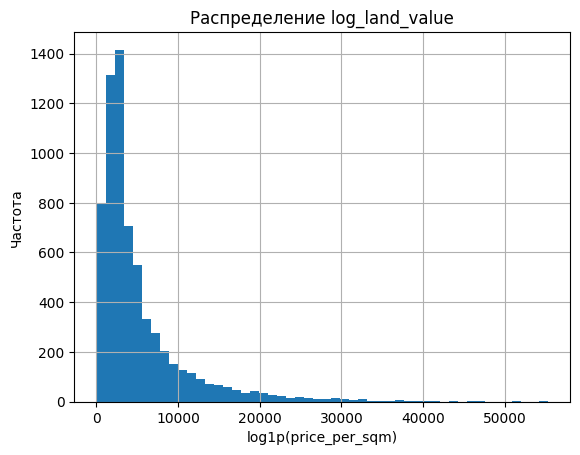

In [14]:

# Гистограмма
plt.figure()
blocks_clean['land_value_per_sqm'].hist(bins=50)
plt.xlabel('log1p(price_per_sqm)')
plt.ylabel('Частота')
plt.title('Распределение log_land_value')
plt.show()

land_value_per_sqm                1.000000
log_land_value_per_sqm            0.849400
fsi                               0.717461
gsi                               0.629976
l                                 0.498940
log_land_value                    0.422247
share_non_living                  0.419886
share_living                      0.411112
land_value                        0.362059
land_value_class_soft_expected    0.342112
land_value_class_pred             0.340824
land_value_class_soft_3           0.332985
residential                       0.323411
living_area                       0.264750
build_floor_area                  0.256751
population                        0.208979
mxi                               0.197788
non_living_area                   0.193911
footprint_area                    0.112164
land_value_class_soft_2           0.023955
business                          0.007969
osr                              -0.042833
share                            -0.042889
special    

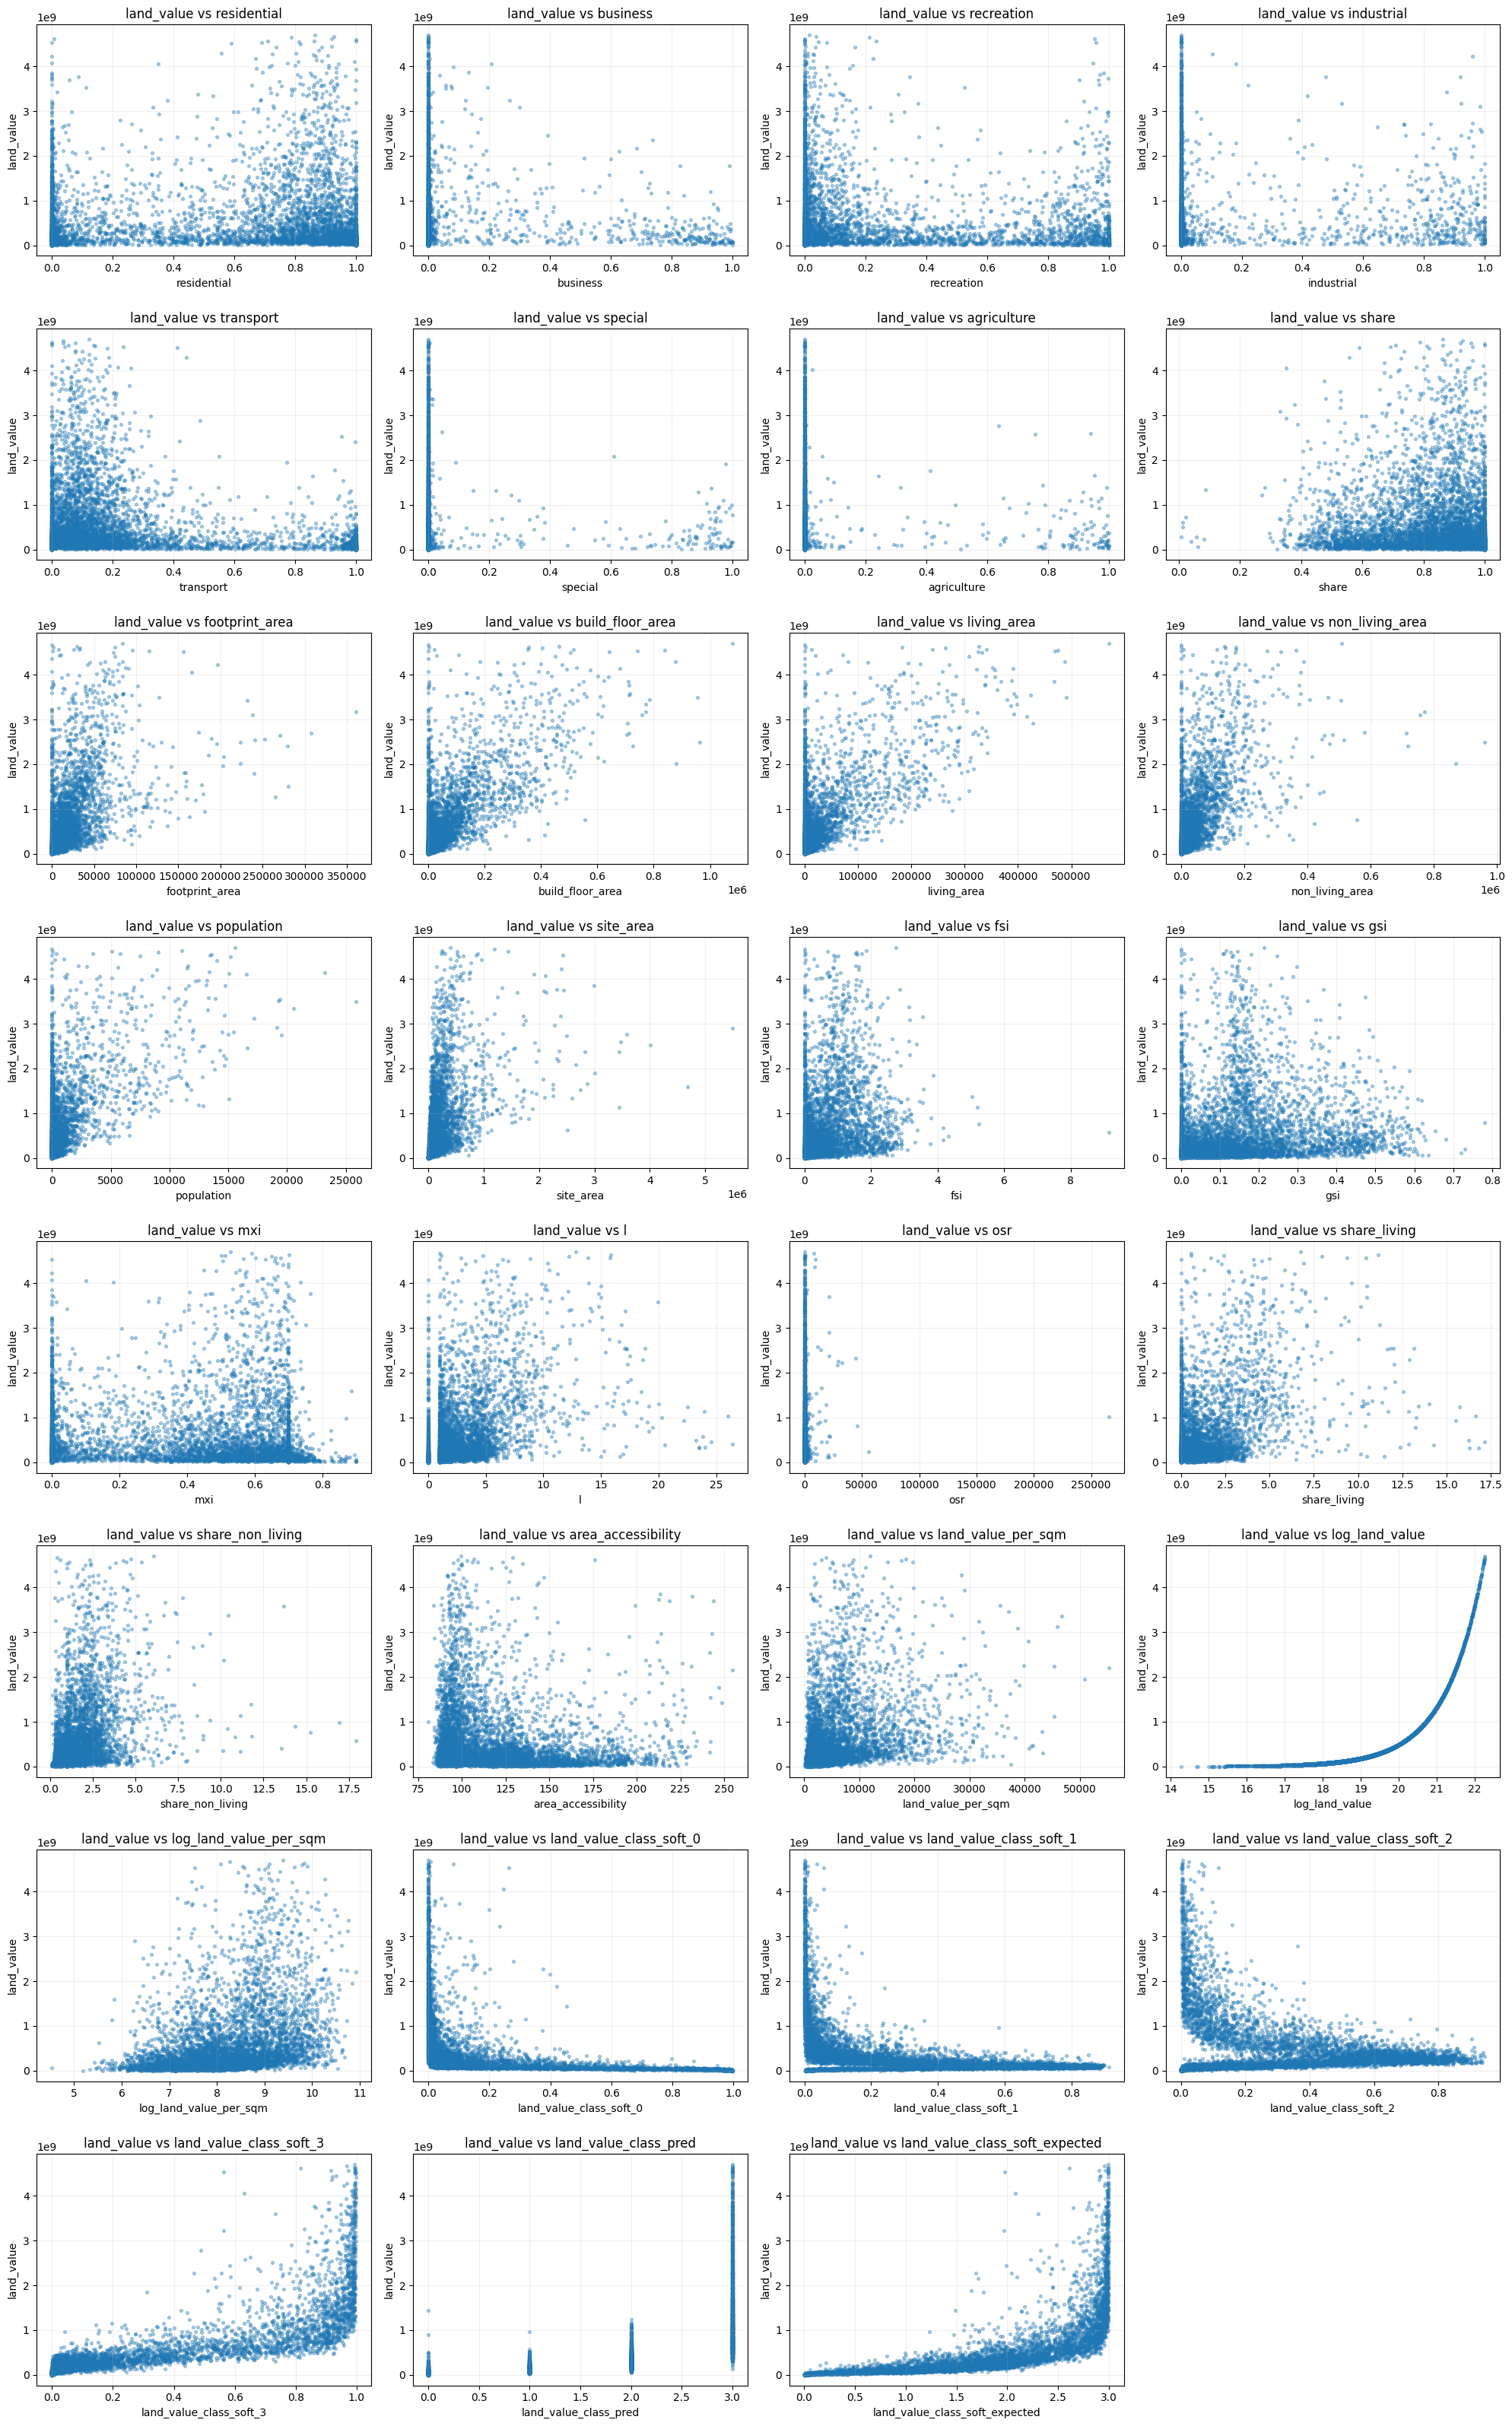

In [15]:
import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

target_col = "land_value_per_sqm"
num_cols = [c for c in blocks_clean.columns if pd.api.types.is_numeric_dtype(blocks_clean[c])]
corr_to_target = (
    blocks_clean[num_cols]
    .corr(method="pearson")[target_col]
    .dropna()
    .sort_values(ascending=False)
)
display(corr_to_target)

# Целевая переменная
target_col = "land_value"

# Берем все фичи кроме target и geometry
exclude = {target_col, "geometry"}
feature_cols = [c for c in blocks_clean.columns if c not in exclude]

# Числовые фичи для scatter
num_features = [
    c for c in feature_cols
    if pd.api.types.is_numeric_dtype(blocks_clean[c])
]

# Подготовка
n = len(num_features)
ncols = 4
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows), squeeze=False)
axes = axes.flatten()

for i, col in enumerate(num_features):
    tmp = blocks_clean[[col, target_col]].dropna()
    axes[i].scatter(tmp[col], tmp[target_col], s=8, alpha=0.35)
    axes[i].set_title(f"{target_col} vs {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(target_col)
    axes[i].grid(alpha=0.2)

# Удаляем пустые оси
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [16]:
# q = blocks_clean["land_value_per_sqm"].quantile(0.99)
# blocks_clean = blocks_clean[blocks_clean["land_value_per_sqm"] < q].copy()
# q = blocks_clean["footprint_area"].quantile(0.99)
# blocks_clean = blocks_clean[blocks_clean["footprint_area"] < q].copy()
# q = blocks_clean["land_value"].quantile(0.99)
# blocks_clean = blocks_clean[blocks_clean["land_value"] < q].copy()
# q = blocks_clean["osr"].quantile(0.99)
# blocks_clean = blocks_clean[blocks_clean["osr"] < q].copy()
# q = blocks_clean["fsi"].quantile(0.99)
# blocks_clean = blocks_clean[blocks_clean["fsi"] < q].copy()
# q = blocks_clean["site_area"].quantile(0.99)
# blocks_clean = blocks_clean[blocks_clean["site_area"] < q].copy()
# q = blocks_clean["living_area"].quantile(0.99)
# blocks_clean = blocks_clean[blocks_clean["living_area"] < q].copy()
# q = blocks_clean["non_living_area"].quantile(0.99)
# blocks_clean = blocks_clean[blocks_clean["non_living_area"] < q].copy()
# q = blocks_clean["share_living"].quantile(0.99)
# blocks_clean = blocks_clean[blocks_clean["share_living"] < q].copy()
# q = blocks_clean["share_non_living"].quantile(0.99)
# blocks_clean = blocks_clean[blocks_clean["share_non_living"] < q].copy()
# q = blocks_clean["population"].quantile(0.99)
# blocks_clean = blocks_clean[blocks_clean["population"] < q].copy()

In [17]:
# q = blocks_clean["land_value_per_sqm"].quantile(0.01)
# blocks_clean = blocks_clean[blocks_clean["land_value_per_sqm"] > q].copy()


# XGBoost

In [18]:
# # === Simple train/test training with XGBoost (без фолдов) ===
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
# import numpy as np
# import pandas as pd
# from xgboost import XGBRegressor

# from urbanomy.methods.land_value_modeling.training_utils import (
#     build_radii_weights,
#     add_lags_full_df,
#     feature_names,
#     to_original_scale,
#     mape,
#     wape,
# )

# # 1) Настройки
# target_col = "log_land_value_per_sqm"
# radius_list = [300, 500, 1000, 2000, 3000]
# test_size = 0.2
# seed = 42
# use_services = False

# exclude_base = {
#     "geometry",
#     "land_value",
#     "land_value_per_sqm",
#     "log_land_value_per_sqm",
#     "log_land_value",
#     "osr",
#     "share_non_living",
#     "share_living",
#     "land_value_class_soft_expected",
#     "district_name",
# }

# cat_features = [c for c in ["land_use", "morphotype"] if c in blocks_clean.columns]

# def is_service_col(col: str) -> bool:
#     return col.lower().startswith("count_")

# # 2) Базовые признаки
# feature_cols = []
# for c in blocks_clean.columns:
#     if c in exclude_base:
#         continue
#     if (not use_services) and is_service_col(c):
#         continue
#     feature_cols.append(c)

# # 3) Подготовка данных + lag-фичи на всем датасете
# data_df = blocks_clean.copy()

# for c in cat_features:
#     data_df[c] = data_df[c].astype("string").fillna("missing")

# numeric_feats = [
#     c for c in feature_cols
#     if c not in cat_features and c != target_col and c in data_df.columns
# ]

# weights = build_radii_weights(data_df, radius_list)
# data_lag = add_lags_full_df(data_df, weights=weights, numeric_cols=numeric_feats)

# base_cols_for_model = list(dict.fromkeys(
#     [c for c in feature_cols if c in data_lag.columns] + cat_features
# ))
# feats = feature_names(data_lag, base_cols_for_model, target_col)

# # 4) Train/test split
# idx_train, idx_test = train_test_split(
#     data_lag.index,
#     test_size=test_size,
#     random_state=seed,
#     shuffle=True,
# )

# df_train = data_lag.loc[idx_train].copy()
# df_test = data_lag.loc[idx_test].copy()

# # 5) Подготовка X / y
# X_train = df_train[feats].copy()
# X_test = df_test[feats].copy()

# # one-hot encoding для категориальных признаков
# cat_feats_for_ohe = [c for c in cat_features if c in X_train.columns]

# X_train = pd.get_dummies(X_train, columns=cat_feats_for_ohe, dummy_na=False)
# X_test = pd.get_dummies(X_test, columns=cat_feats_for_ohe, dummy_na=False)

# # выравниваем набор колонок между train и test
# X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)
# X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# y_train = df_train[target_col].to_numpy()
# y_test = df_test[target_col].to_numpy()

# # 6) Обучение
# model = XGBRegressor(
#     objective="reg:squarederror",
#     eval_metric="rmse",
#     n_estimators=40000,
#     learning_rate=0.03,
#     max_depth=6,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     random_state=seed,
#     n_jobs=-1,
#     early_stopping_rounds=1000,
# )

# model.fit(
#     X_train,
#     y_train,
#     eval_set=[(X_test, y_test)],
#     verbose=200,
# )

# # 7) Метрики на train и test в оригинальной шкале
# # --- Train ---
# y_train_pred_raw = np.asarray(model.predict(X_train)).reshape(-1)
# y_train_true_raw = y_train

# y_train_true = to_original_scale(y_train_true_raw, target_col=target_col)
# y_train_pred = to_original_scale(y_train_pred_raw, target_col=target_col)

# train_mape = mape(y_train_true, y_train_pred)
# train_wape = wape(y_train_true, y_train_pred)
# train_r2 = r2_score(y_train_true, y_train_pred)
# train_mae = mean_absolute_error(y_train_true, y_train_pred)
# train_rmse = np.sqrt(mean_squared_error(y_train_true, y_train_pred))

# # --- Test ---
# y_test_pred_raw = np.asarray(model.predict(X_test)).reshape(-1)
# y_test_true_raw = y_test

# y_test_true = to_original_scale(y_test_true_raw, target_col=target_col)
# y_test_pred = to_original_scale(y_test_pred_raw, target_col=target_col)

# test_mape = mape(y_test_true, y_test_pred)
# test_wape = wape(y_test_true, y_test_pred)
# test_r2 = r2_score(y_test_true, y_test_pred)
# test_mae = mean_absolute_error(y_test_true, y_test_pred)
# test_rmse = np.sqrt(mean_squared_error(y_test_true, y_test_pred))

# print("Train metrics:")
# print(f"MAPE: {train_mape:.6f} ({train_mape*100:.2f}%)")
# print(f"WAPE: {train_wape:.6f} ({train_wape*100:.2f}%)")
# print(f"MAE:  {train_mae:.6f}")
# print(f"RMSE: {train_rmse:.6f}")
# print(f"R2:   {train_r2:.6f}")

# print("\nTest metrics:")
# print(f"MAPE: {test_mape:.6f} ({test_mape*100:.2f}%)")
# print(f"WAPE: {test_wape:.6f} ({test_wape*100:.2f}%)")
# print(f"MAE:  {test_mae:.6f}")
# print(f"RMSE: {test_rmse:.6f}")
# print(f"R2:   {test_r2:.6f}")


# CatBoost

In [29]:
# === Simple train/test training (без фолдов) + дообучение на всем датасете ===
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
from catboost import CatBoostRegressor, Pool

from urbanomy.methods.land_value_modeling.training_utils import (
    build_radii_weights,
    add_lags_full_df,
    feature_names,
    to_original_scale,
    mape,
    wape,
)

# 1) Настройки
target_col = "log_land_value"
radius_list = [500, 1000, 2000, 3000]
test_size = 0.2
seed = 42
use_services = False

exclude_base = {
    "geometry",
    "land_value",
    "land_value_per_sqm",
    "log_land_value_per_sqm",
    "log_land_value",
    "osr",
    "share_non_living",
    "share_living",
    # "land_value_class_soft_0",
    # "land_value_class_soft_1",
    # "land_value_class_soft_2",
    # "land_value_class_soft_3",
    # "land_value_class_soft_4",
    # "land_value_class_pred",
    "land_value_class_soft_expected",
    "district_name",
    "number_of_floors",
}
cat_features = [c for c in ["land_use", "morphotype"] if c in blocks_clean.columns]

def is_service_col(col: str) -> bool:
    return col.lower().startswith("count_")

# 2) Базовые признаки
feature_cols = []
for c in blocks_clean.columns:
    if c in exclude_base:
        continue
    if (not use_services) and is_service_col(c):
        continue
    feature_cols.append(c)

# 3) Подготовка данных + lag-фичи на всем датасете
data_df = blocks_clean.copy()
for c in cat_features:
    data_df[c] = data_df[c].astype("string").fillna("missing")

numeric_feats = [
    c for c in feature_cols
    if c not in cat_features and c != target_col and c in data_df.columns
]

weights = build_radii_weights(data_df, radius_list)
data_lag = add_lags_full_df(data_df, weights=weights, numeric_cols=numeric_feats)

base_cols_for_model = list(dict.fromkeys([c for c in feature_cols if c in data_lag.columns] + cat_features))
feats = feature_names(data_lag, base_cols_for_model, target_col)
cat_features_used = [c for c in cat_features if c in feats]

# 4) Один train/test split (без кросс-валидации)
idx_train, idx_test = train_test_split(
    data_lag.index,
    test_size=test_size,
    random_state=seed,
    shuffle=True,
)

df_train = data_lag.loc[idx_train].copy()
df_test = data_lag.loc[idx_test].copy()

train_pool = Pool(df_train[feats], label=df_train[target_col], cat_features=cat_features_used, feature_names=feats)
test_pool = Pool(df_test[feats], label=df_test[target_col], cat_features=cat_features_used, feature_names=feats)

# 5) Обучение и подбор лучшей длины бустинга на holdout
base_params = dict(
    loss_function="MAE",
    eval_metric="MAE",
    learning_rate=0.03,
    depth=8,
    subsample=0.8,
    rsm=0.8,
    random_seed=seed,
)

model_eval = CatBoostRegressor(
    **base_params,
    iterations=20000,
    od_type="Iter",
    od_wait=2000,
    verbose=200,
)

model_eval.fit(
    train_pool,
    eval_set=test_pool,
    early_stopping_rounds=600,
    use_best_model=True,
)

# 6) Метрики на train и test в оригинальной шкале
# --- Train ---
y_train_pred_raw = np.asarray(model_eval.predict(df_train[feats])).reshape(-1)
y_train_true_raw = df_train[target_col].to_numpy()

y_train_true = to_original_scale(y_train_true_raw, target_col=target_col)
y_train_pred = to_original_scale(y_train_pred_raw, target_col=target_col)

train_mape = mape(y_train_true, y_train_pred)
train_wape = wape(y_train_true, y_train_pred)
train_r2 = r2_score(y_train_true, y_train_pred)
train_mae = mean_absolute_error(y_train_true, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train_true, y_train_pred))

# --- Test ---
y_test_pred_raw = np.asarray(model_eval.predict(df_test[feats])).reshape(-1)
y_test_true_raw = df_test[target_col].to_numpy()

y_test_true = to_original_scale(y_test_true_raw, target_col=target_col)
y_test_pred = to_original_scale(y_test_pred_raw, target_col=target_col)

test_mape = mape(y_test_true, y_test_pred)
test_wape = wape(y_test_true, y_test_pred)
test_r2 = r2_score(y_test_true, y_test_pred)
test_mae = mean_absolute_error(y_test_true, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test_true, y_test_pred))

print("Train metrics:")
print(f"MAPE: {train_mape:.6f} ({train_mape*100:.2f}%)")
print(f"WAPE: {train_wape:.6f} ({train_wape*100:.2f}%)")
print(f"MAE:  {train_mae:.6f}")
print(f"RMSE: {train_rmse:.6f}")
print(f"R2:   {train_r2:.6f}")

print("\nTest metrics:")
print(f"MAPE: {test_mape:.6f} ({test_mape*100:.2f}%)")
print(f"WAPE: {test_wape:.6f} ({test_wape*100:.2f}%)")
print(f"MAE:  {test_mae:.6f}")
print(f"RMSE: {test_rmse:.6f}")
print(f"R2:   {test_r2:.6f}")

# 7) Финальное обучение на всем датасете после расчета метрик
# Берем оптимальное число итераций с holdout-модели
best_iter = model_eval.get_best_iteration()
final_iterations = int(best_iter + 1) if best_iter is not None and best_iter >= 0 else 20000

full_pool = Pool(
    data_lag[feats],
    label=data_lag[target_col],
    cat_features=cat_features_used,
    feature_names=feats,
)

model = CatBoostRegressor(
    **base_params,
    iterations=final_iterations,
    verbose=200,
)

model.fit(full_pool)

print(f"\nFinal model trained on full dataset with iterations={final_iterations}")


0:	learn: 1.0605336	test: 1.0786167	best: 1.0786167 (0)	total: 16.3ms	remaining: 5m 26s
200:	learn: 0.2398672	test: 0.2787730	best: 0.2787730 (200)	total: 2.54s	remaining: 4m 9s
400:	learn: 0.1953251	test: 0.2637394	best: 0.2637394 (400)	total: 5.05s	remaining: 4m 6s
600:	learn: 0.1643089	test: 0.2576169	best: 0.2575890 (599)	total: 7.7s	remaining: 4m 8s
800:	learn: 0.1431275	test: 0.2541867	best: 0.2541864 (799)	total: 10.7s	remaining: 4m 16s
1000:	learn: 0.1289580	test: 0.2521991	best: 0.2521991 (1000)	total: 13.5s	remaining: 4m 16s
1200:	learn: 0.1179534	test: 0.2510966	best: 0.2510442 (1183)	total: 16s	remaining: 4m 10s
1400:	learn: 0.1084365	test: 0.2496069	best: 0.2495784 (1397)	total: 18.3s	remaining: 4m 3s
1600:	learn: 0.1010257	test: 0.2486855	best: 0.2486827 (1598)	total: 20.7s	remaining: 3m 57s
1800:	learn: 0.0953046	test: 0.2479999	best: 0.2479880 (1781)	total: 23s	remaining: 3m 52s
2000:	learn: 0.0901246	test: 0.2474133	best: 0.2473966 (1976)	total: 25.5s	remaining: 3m 49s

In [ ]:
# model_path = f"catboost_land_value_{'with_services' if use_services else 'no_services'}.cbm"
# model.save_model(model_path)
# print(model_path)

catboost_land_value_no_services.cbm


In [30]:
# === Предсказание на всем blocks_clean + таблица ошибок ===
import numpy as np
import pandas as pd

# 1) Предсказание на всех строках (используем уже подготовленный data_lag и feats)
df_all = data_lag.loc[blocks_clean.index].copy()

y_pred_raw = np.asarray(model.predict(df_all[feats])).reshape(-1)
y_true_raw = df_all[target_col].to_numpy()

# Перевод в оригинальную шкалу (например, из log -> обычная стоимость)
y_true = to_original_scale(y_true_raw, target_col=target_col)
y_pred = to_original_scale(y_pred_raw, target_col=target_col)

# 2) Процент ошибки по каждой записи
eps = 1e-12
error_pct = np.where(
    np.abs(y_true) > eps,
    np.abs(y_pred - y_true) / np.abs(y_true) * 100.0,
    np.nan
)

# 3) Итоговый датафрейм
value_col_name = (
    "land_value_per_sqm" if target_col == "log_land_value_per_sqm"
    else "land_value" if target_col == "log_land_value"
    else "target_value"
)

result_df = blocks_clean.copy()
result_df[f"current_{value_col_name}"] = y_true
result_df[f"pred_{value_col_name}"] = y_pred
result_df["error_pct"] = error_pct
result_df["abs_error"] = np.abs(y_pred - y_true)

# 4) Суммарный процент ошибки
# MAPE = средний % ошибки
total_mape_pct = np.nanmean(error_pct)

# WAPE = суммарная абсолютная ошибка / суммарное фактическое значение
total_wape_pct = (np.nansum(np.abs(y_pred - y_true)) / np.nansum(np.abs(y_true))) * 100.0

print(f"Суммарная ошибка (MAPE): {total_mape_pct:.2f}%")
print(f"Суммарная ошибка (WAPE): {total_wape_pct:.2f}%")


display(result_df[[f"current_{value_col_name}", f"pred_{value_col_name}", "error_pct"]].head(20))


Суммарная ошибка (MAPE): 3.88%
Суммарная ошибка (WAPE): 3.14%


,current_land_value,pred_land_value,error_pct
0,1.292022e+08,1.298989e+08,0.539251
1,1.859462e+08,1.860686e+08,0.065862
2,1.897886e+08,1.898774e+08,0.046826
3,3.733097e+08,3.731729e+08,0.036653
4,5.614886e+07,5.564111e+07,0.904292
5,3.113808e+07,3.116438e+07,0.084468
7,1.645667e+08,1.696751e+08,3.104195
8,1.868658e+08,1.881814e+08,0.704034
9,8.076586e+07,8.963049e+07,10.975723
10,4.548499e+08,4.560563e+08,0.265241


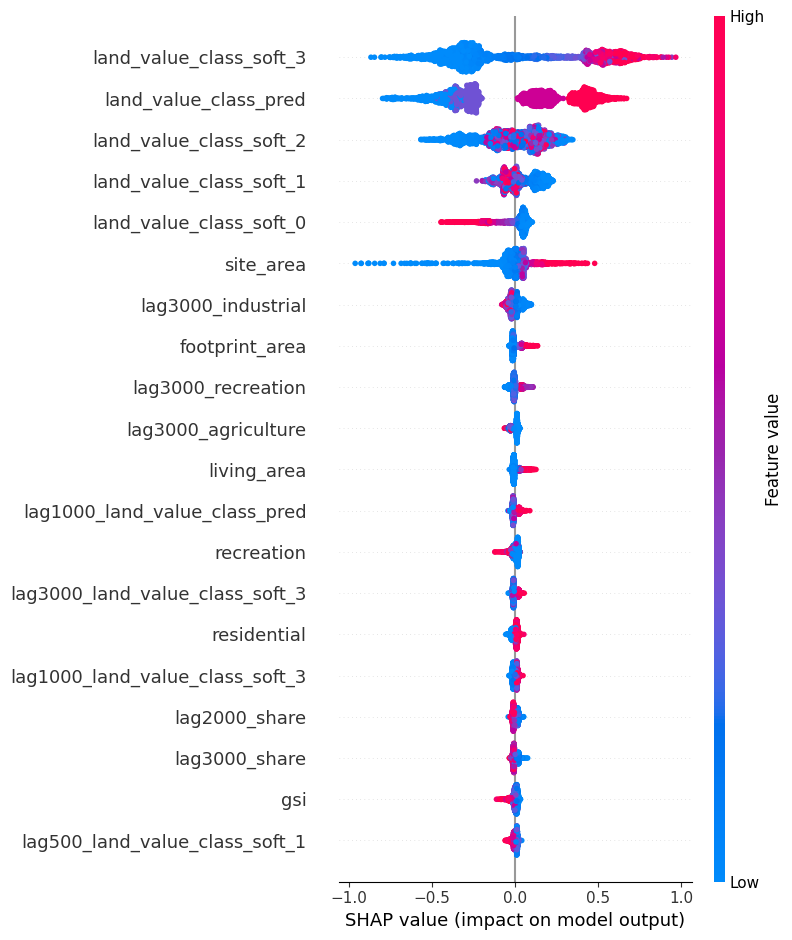

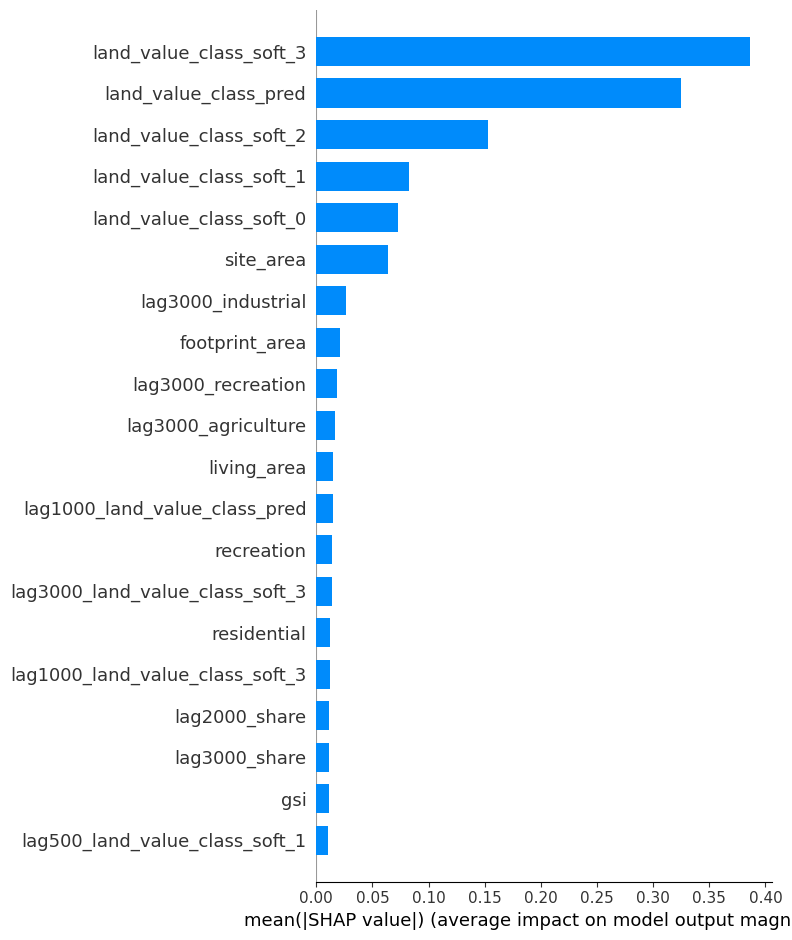

In [31]:
# === SHAP через библиотеку shap: beeswarm + bar для текущей модели ===
import shap
import numpy as np

from urbanomy.methods.land_value_modeling.training_utils import (
    prep_cat_inplace,
    build_radii_weights,
    add_lags_full_df,
    feature_names,
)

# Используем переменные из твоего трейнинга:
# target_col, feature_cols, cat_features, radius_list, blocks_clean, model

numeric_feats = [
    c for c in feature_cols
    if c not in cat_features and c != target_col and c in blocks_clean.columns
]

work_df = blocks_clean.copy()
prep_cat_inplace(work_df, cat_features)

weights_shap = build_radii_weights(work_df, radius_list)
data_lag_shap = add_lags_full_df(work_df, weights=weights_shap, numeric_cols=numeric_feats)

base_cols_for_model = list(dict.fromkeys(list(feature_cols) + list(cat_features)))
feats = feature_names(data_lag_shap, base_cols_for_model, target_col)

X_shap = data_lag_shap[feats].copy()

# Опционально: сэмпл для ускорения
max_rows = 3000
if len(X_shap) > max_rows:
    X_shap = X_shap.sample(max_rows, random_state=42)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap)

# Для совместимости с разными версиями shap/catboost
if isinstance(shap_values, list):
    shap_values = shap_values[0]

# 1) Beeswarm
shap.summary_plot(shap_values, X_shap, feature_names=feats, show=True)

# 2) Bar (mean |SHAP|)
shap.summary_plot(shap_values, X_shap, feature_names=feats, plot_type="bar", show=True)


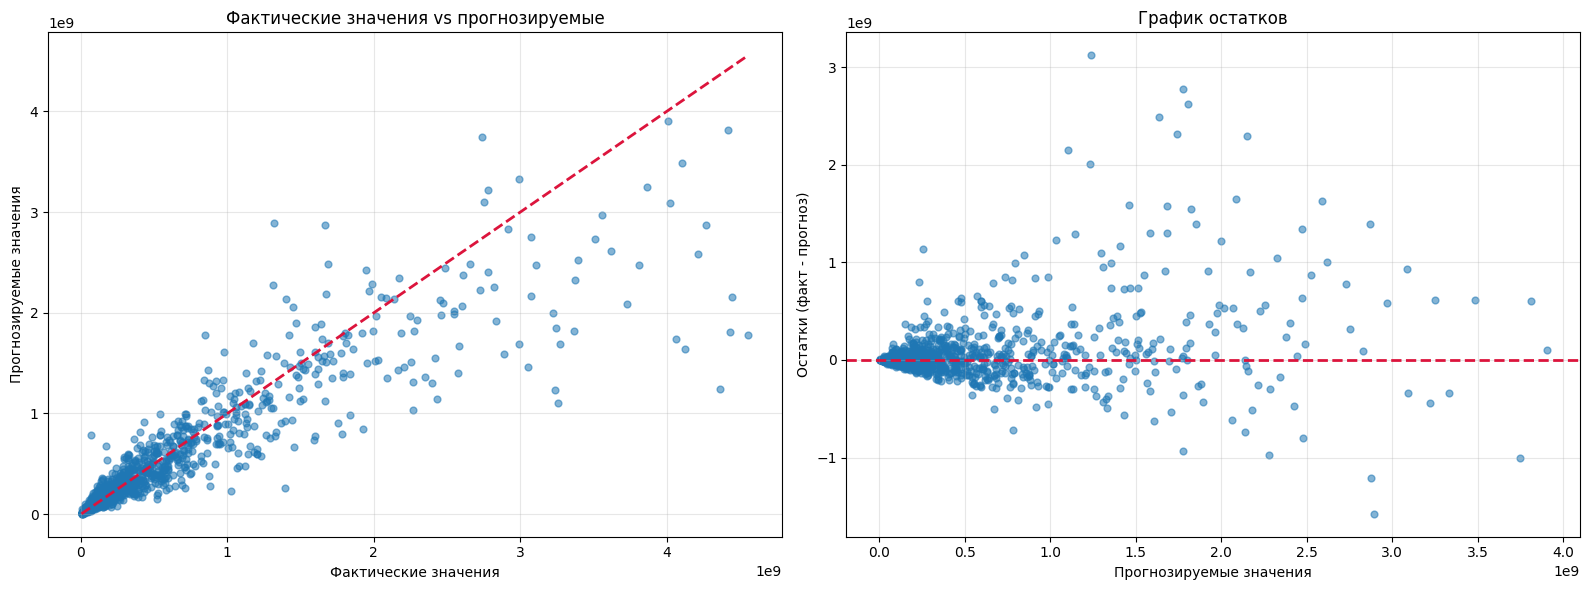

In [25]:
import numpy as np
import matplotlib.pyplot as plt

plot_mask = np.isfinite(y_test_true) & np.isfinite(y_test_pred)
y_true_plot = y_test_true[plot_mask]
y_pred_plot = y_test_pred[plot_mask]
residuals = y_true_plot - y_pred_plot

min_val = min(y_true_plot.min(), y_pred_plot.min())
max_val = max(y_true_plot.max(), y_pred_plot.max())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Разброс фактических значений по сравнению с прогнозируемыми
axes[0].scatter(y_true_plot, y_pred_plot, alpha=0.55, s=24)
axes[0].plot(
    [min_val, max_val],
    [min_val, max_val],
    color="crimson",
    linestyle="--",
    linewidth=2,
)
axes[0].set_title("Фактические значения vs прогнозируемые")
axes[0].set_xlabel("Фактические значения")
axes[0].set_ylabel("Прогнозируемые значения")
axes[0].grid(alpha=0.3)

# 2. График остатков
axes[1].scatter(y_pred_plot, residuals, alpha=0.55, s=24)
axes[1].axhline(0, color="crimson", linestyle="--", linewidth=2)
axes[1].set_title("График остатков")
axes[1].set_xlabel("Прогнозируемые значения")
axes[1].set_ylabel("Остатки (факт - прогноз)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()



In [24]:
# import re
# import numpy as np
# import pandas as pd
# from catboost import CatBoostRegressor, Pool
# from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# # 1) Разбиваем фичи на base / lag-группы по радиусам
# lag_groups = {r: [] for r in radius_list}
# other_lag_feats = []
# base_feats = []

# for f in feats:
#     matched = False
#     for r in radius_list:
#         if f.startswith(f"lag{r}_"):
#             lag_groups[r].append(f)
#             matched = True
#             break

#     if matched:
#         continue

#     if f.startswith("lag"):
#         other_lag_feats.append(f)
#     else:
#         base_feats.append(f)

# print("Base feats:", len(base_feats))
# for r in radius_list:
#     print(f"Lag feats radius {r}: {len(lag_groups[r])}")
# print("Other lag feats:", len(other_lag_feats))



# # 2) Универсальная функция оценки
# def evaluate_feature_set(feature_set, name):
#     feature_set = list(dict.fromkeys(feature_set))
#     feature_set = [f for f in feature_set if f in df_train.columns and f in df_test.columns]
#     cat_subset = [c for c in cat_features if c in feature_set]

#     train_pool = Pool(
#         df_train[feature_set],
#         label=df_train[target_col],
#         cat_features=cat_subset,
#         feature_names=feature_set,
#     )
#     test_pool = Pool(
#         df_test[feature_set],
#         label=df_test[target_col],
#         cat_features=cat_subset,
#         feature_names=feature_set,
#     )

#     model = CatBoostRegressor(
#         loss_function="MAE",
#         eval_metric="MAE",
#         iterations=5000,
#         od_type="Iter",
#         od_wait=300,
#         random_seed=seed,
#         verbose=False,
#     )

#     model.fit(
#         train_pool,
#         eval_set=test_pool,
#         early_stopping_rounds=300,
#         use_best_model=True,
#         verbose=False,
#     )

#     y_train_pred_raw = np.asarray(model.predict(df_train[feature_set])).reshape(-1)
#     y_test_pred_raw = np.asarray(model.predict(df_test[feature_set])).reshape(-1)

#     y_train_true_raw = df_train[target_col].to_numpy()
#     y_test_true_raw = df_test[target_col].to_numpy()

#     y_train_true = to_original_scale(y_train_true_raw, target_col=target_col)
#     y_train_pred = to_original_scale(y_train_pred_raw, target_col=target_col)

#     y_test_true = to_original_scale(y_test_true_raw, target_col=target_col)
#     y_test_pred = to_original_scale(y_test_pred_raw, target_col=target_col)

#     return {
#         "set_name": name,
#         "n_features": len(feature_set),
#         "best_iteration": model.get_best_iteration() + 1 if model.get_best_iteration() is not None else None,
#         "train_mape": mape(y_train_true, y_train_pred),
#         "train_wape": wape(y_train_true, y_train_pred),
#         "train_mae": mean_absolute_error(y_train_true, y_train_pred),
#         "train_rmse": np.sqrt(mean_squared_error(y_train_true, y_train_pred)),
#         "train_r2": r2_score(y_train_true, y_train_pred),
#         "test_mape": mape(y_test_true, y_test_pred),
#         "test_wape": wape(y_test_true, y_test_pred),
#         "test_mae": mean_absolute_error(y_test_true, y_test_pred),
#         "test_rmse": np.sqrt(mean_squared_error(y_test_true, y_test_pred)),
#         "test_r2": r2_score(y_test_true, y_test_pred),
#         "features": feature_set,
#         "model": model,
#     }

# # 3) Наборы для ablation
# candidate_sets = {
#     "base_only": base_feats,
# }

# for r in radius_list:
#     candidate_sets[f"base_plus_r{r}"] = base_feats + lag_groups[r]

# cumulative = []
# for r in radius_list:
#     cumulative = cumulative + lag_groups[r]
#     candidate_sets[f"base_plus_to_r{r}"] = base_feats + cumulative

# if len(other_lag_feats) > 0:
#     candidate_sets["base_plus_other_lags"] = base_feats + other_lag_feats
#     candidate_sets["all_features"] = base_feats + cumulative + other_lag_feats
# else:
#     candidate_sets["all_features"] = base_feats + cumulative

# # 4) Прогон
# ablation_results = []
# ablation_models = {}

# for name, feature_set in candidate_sets.items():
#     res = evaluate_feature_set(feature_set, name)
#     ablation_models[name] = res["model"]
#     ablation_results.append({k: v for k, v in res.items() if k not in ["features", "model"]})

# ablation_df = (
#     pd.DataFrame(ablation_results)
#     .sort_values(["test_mae", "test_wape", "test_rmse"], ascending=True)
#     .reset_index(drop=True)
# )

# display(ablation_df)

# best_ablation_name = ablation_df.iloc[0]["set_name"]
# print("Best ablation set:", best_ablation_name)


In [25]:
# # === Simple train/test training with selected features ===
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
# import numpy as np
# from catboost import CatBoostRegressor, Pool
# from urbanomy.methods.land_value_modeling.training_utils import (
#     build_radii_weights,
#     add_lags_full_df,
#     feature_names,
#     to_original_scale,
#     mape,
#     wape,
# )
# selected_features = candidate_sets["base_plus_r3000"]

# # 1) Настройки
# target_col = "land_value_per_sqm"
# radius_list = [300, 500, 1000, 2000, 3000]
# test_size = 0.1
# seed = 42
# use_services = False

# # Сюда можно передать отобранные фичи, например:
# # selected_features = top_60_features
# selected_features = None

# exclude_base = {
#     "geometry",
#     "land_value",
#     "land_value_per_sqm",
#     "log_land_value_per_sqm",
#     "log_land_value",
#     "osr",
#     "share_non_living",
#     "share_living",
#     "land_value_class_soft_expected",
#     "district_name",
# }

# cat_features = [c for c in ["land_use", "morphotype"] if c in blocks_clean.columns]

# def is_service_col(col: str) -> bool:
#     return col.lower().startswith("count_")

# # 2) Базовые признаки
# feature_cols = []
# for c in blocks_clean.columns:
#     if c in exclude_base:
#         continue
#     if (not use_services) and is_service_col(c):
#         continue
#     feature_cols.append(c)

# # 3) Подготовка данных + lag-фичи
# data_df = blocks_clean.copy()

# for c in cat_features:
#     data_df[c] = data_df[c].astype("string").fillna("missing")

# numeric_feats = [
#     c for c in feature_cols
#     if c not in cat_features and c != target_col and c in data_df.columns
# ]

# weights = build_radii_weights(data_df, radius_list)
# data_lag = add_lags_full_df(data_df, weights=weights, numeric_cols=numeric_feats)

# base_cols_for_model = list(dict.fromkeys(
#     [c for c in feature_cols if c in data_lag.columns] + cat_features
# ))
# all_feats = feature_names(data_lag, base_cols_for_model, target_col)

# selected_features = candidate_sets["base_plus_r3000"]

# # 4) Выбор фичей для обучения
# if selected_features is None:
#     feats = all_feats
# else:
#     feats = [f for f in selected_features if f in all_feats]
#     if len(feats) == 0:
#         raise ValueError("selected_features is empty after filtering by available model features")

# cat_features_model = [c for c in cat_features if c in feats]

# print(f"Total available features: {len(all_feats)}")
# print(f"Selected features for training: {len(feats)}")

# # 5) Train/test split
# idx_train, idx_test = train_test_split(
#     data_lag.index,
#     test_size=test_size,
#     random_state=seed,
#     shuffle=True,
# )

# df_train = data_lag.loc[idx_train].copy()
# df_test = data_lag.loc[idx_test].copy()

# train_pool = Pool(
#     df_train[feats],
#     label=df_train[target_col],
#     cat_features=cat_features_model,
#     feature_names=feats,
# )
# test_pool = Pool(
#     df_test[feats],
#     label=df_test[target_col],
#     cat_features=cat_features_model,
#     feature_names=feats,
# )

# # 6) Обучение
# model = CatBoostRegressor(
#     loss_function="MAE",
#     eval_metric="MAE",
#     iterations=20000,
#     od_type="Iter",
#     od_wait=2000,
#     random_seed=seed,
#     verbose=200,
# )

# model.fit(
#     train_pool,
#     eval_set=test_pool,
#     early_stopping_rounds=600,
#     use_best_model=True,
# )

# # 7) Метрики на train/test в оригинальной шкале
# # --- Train ---
# y_train_pred_raw = np.asarray(model.predict(df_train[feats])).reshape(-1)
# y_train_true_raw = df_train[target_col].to_numpy()

# y_train_true = to_original_scale(y_train_true_raw, target_col=target_col)
# y_train_pred = to_original_scale(y_train_pred_raw, target_col=target_col)

# train_mape = mape(y_train_true, y_train_pred)
# train_wape = wape(y_train_true, y_train_pred)
# train_r2 = r2_score(y_train_true, y_train_pred)
# train_mae = mean_absolute_error(y_train_true, y_train_pred)
# train_rmse = np.sqrt(mean_squared_error(y_train_true, y_train_pred))

# # --- Test ---
# y_test_pred_raw = np.asarray(model.predict(df_test[feats])).reshape(-1)
# y_test_true_raw = df_test[target_col].to_numpy()

# y_test_true = to_original_scale(y_test_true_raw, target_col=target_col)
# y_test_pred = to_original_scale(y_test_pred_raw, target_col=target_col)

# test_mape = mape(y_test_true, y_test_pred)
# test_wape = wape(y_test_true, y_test_pred)
# test_r2 = r2_score(y_test_true, y_test_pred)
# test_mae = mean_absolute_error(y_test_true, y_test_pred)
# test_rmse = np.sqrt(mean_squared_error(y_test_true, y_test_pred))

# print("Train metrics:")
# print(f"MAPE: {train_mape:.6f} ({train_mape*100:.2f}%)")
# print(f"WAPE: {train_wape:.6f} ({train_wape*100:.2f}%)")
# print(f"MAE:  {train_mae:.6f}")
# print(f"RMSE: {train_rmse:.6f}")
# print(f"R2:   {train_r2:.6f}")

# print("\nTest metrics:")
# print(f"MAPE: {test_mape:.6f} ({test_mape*100:.2f}%)")
# print(f"WAPE: {test_wape:.6f} ({test_wape*100:.2f}%)")
# print(f"MAE:  {test_mae:.6f}")
# print(f"RMSE: {test_rmse:.6f}")
# print(f"R2:   {test_r2:.6f}")


In [26]:
# import matplotlib.pyplot as plt
# import numpy as np

# fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=False, sharey=False)

# # Train
# axes[0].scatter(y_train_true, y_train_pred, alpha=0.35, s=20)
# mn = min(y_train_true.min(), y_train_pred.min())
# mx = max(y_train_true.max(), y_train_pred.max())
# axes[0].plot([mn, mx], [mn, mx], "r--", linewidth=2)
# axes[0].set_title("Train: true vs predicted price")
# axes[0].set_xlabel("True price")
# axes[0].set_ylabel("Predicted price")
# axes[0].grid(alpha=0.3)

# # Test
# axes[1].scatter(y_test_true, y_test_pred, alpha=0.35, s=20)
# mn = min(y_test_true.min(), y_test_pred.min())
# mx = max(y_test_true.max(), y_test_pred.max())
# axes[1].plot([mn, mx], [mn, mx], "r--", linewidth=2)
# axes[1].set_title("Test: true vs predicted price")
# axes[1].set_xlabel("True price")
# axes[1].set_ylabel("Predicted price")
# axes[1].grid(alpha=0.3)

# plt.tight_layout()
# plt.show()


# Основное обучение

In [ ]:
from urbanomy.methods.land_value_modeling.training_utils import TrainingConfig, run_training
import logging

# Флаг: учить с сервисами (count_*) или без
use_services = False   # False -> исключаем все count_* фичи

target_col = "land_value"
radius_list = [500, 1000, 2000, 3000]


exclude_base = {
    "geometry",
    "land_value",
    "land_value_per_sqm",
    "log_land_value_per_sqm",
    "log_land_value",
    "osr",
    "share_non_living",
    "share_living",
    'land_value_class_soft_0',
    'land_value_class_soft_1',
    'land_value_class_soft_2',
    'land_value_class_soft_3',
    'land_value_class_soft_4',
    'land_value_class_pred',
    "land_value_class_soft_expected",
    'district_name',
    'number_of_floors',
}

def is_service_col(col: str) -> bool:
    # сервисы у тебя обычно в формате count_...
    # если есть другие варианты (например Count_ / COUNT_), делаем lower()
    c = col.lower()
    return c.startswith("count_")

# формируем feature_cols с учетом флага
feature_cols = []
for c in blocks.columns:
    if c in exclude_base:
        continue
    if (not use_services) and is_service_col(c):
        continue
    feature_cols.append(c)

cat_features = ["land_use", "morphotype", 'land_value_class_pred',]

cfg = TrainingConfig(
    feature_cols=feature_cols,
    cat_features=cat_features,
    radius_list=radius_list,
    target_col=target_col,
    group_col="district_name",
    loss_function="MAE",
    eval_metric="MAE",
    hpo_iter=5,
    param_grid={
        "depth": [6],
        "learning_rate": [0.03],
        "l2_leaf_reg": [3],
        "random_strength": [1.0],
        "bagging_temperature": [1.0],
    },
    # n_clusters=20,
    inner_splits=1,
    outer_splits=5,
    iterations=20000,
    od_wait=2000,
    seed=42,
)

model, metrics = run_training(
    blocks_clean,
    cfg,
    log_path=f"catboost_info/training_{'with_services' if use_services else 'no_services'}.log",
    console_level=logging.WARNING,
)

print("use_services =", use_services)


[run_training] outer_splits=5, inner_splits=1, hpo_iter=5
[run_training] group_col='district_name' is set; n_clusters=10 is ignored.
[run_training] HPO skipped: param_grid has one combination: {'depth': 6, 'learning_rate': 0.03, 'l2_leaf_reg': 3, 'random_strength': 1.0, 'bagging_temperature': 1.0}
[run_training] hpo_iter=5 ignored because only one params combination is available.


OuterCV:   0%|          | 0/5 [00:00<?, ?it/s]

0:	learn: 0.6541698	total: 5.77ms	remaining: 14.6s
200:	learn: 0.2788146	total: 654ms	remaining: 7.57s
400:	learn: 0.2432137	total: 1.44s	remaining: 7.65s
600:	learn: 0.2201371	total: 2.15s	remaining: 6.88s
800:	learn: 0.2038445	total: 2.88s	remaining: 6.21s
1000:	learn: 0.1910998	total: 3.58s	remaining: 5.46s
1200:	learn: 0.1814242	total: 4.29s	remaining: 4.74s
1400:	learn: 0.1732110	total: 5.13s	remaining: 4.12s
1600:	learn: 0.1661663	total: 5.88s	remaining: 3.4s
1800:	learn: 0.1601619	total: 6.53s	remaining: 2.63s
2000:	learn: 0.1548944	total: 7.43s	remaining: 1.95s
2200:	learn: 0.1501413	total: 8.2s	remaining: 1.21s
2400:	learn: 0.1459591	total: 9.01s	remaining: 473ms
2526:	learn: 0.1435505	total: 9.42s	remaining: 0us
2026-03-10 17:32:39,109 | WARNING | Train metrics:
MAPE: 0.148098 (14.81%)
WAPE: 0.154543 (15.45%)
MAE:  780.693650
RMSE: 1705.932171
R2:   0.874576

Test metrics:
MAPE: 0.377907 (37.79%)
WAPE: 0.340303 (34.03%)
MAE:  1727.176316
RMSE: 2813.121175
R2:   0.586453
use_s

In [ ]:
district_counts = (
    blocks_clean
    .assign(district_name=blocks_clean["district_name"].astype("string").fillna("missing"))
    .groupby("district_name", dropna=False)
    .size()
    .reset_index(name="n_blocks")
    .sort_values("n_blocks", ascending=False)
)

display(district_counts)


,district_name,n_blocks
9,Курортный район,733
7,Красносельский район,656
15,Пушкинский район,627
14,Приморский район,484
13,Петродворцовый район,452
2,Выборгский район,382
5,Колпинский район,263
17,Центральный район,226
11,Невский район,214
6,Красногвардейский район,214


In [ ]:
from sklearn.model_selection import GroupKFold
import pandas as pd

groups = pd.factorize(blocks_clean["district_name"].astype("string").fillna("missing_group"))[0]
gkf = GroupKFold(n_splits=cfg.outer_splits)

for i, (train_idx, test_idx) in enumerate(
    gkf.split(blocks_clean, blocks_clean[cfg.target_col], groups), 1
):
    print(f"Fold {i}")
    print(f"  train rows: {len(train_idx)}")
    print(f"  test rows:  {len(test_idx)}")
    print(f"  train districts: {len(set(groups[train_idx]))}")
    print(f"  test districts:  {len(set(groups[test_idx]))}")


Fold 1
  train rows: 5561
  test rows:  1387
  train districts: 15
  test districts:  3
Fold 2
  train rows: 5627
  test rows:  1321
  train districts: 15
  test districts:  3
Fold 3
  train rows: 5531
  test rows:  1417
  train districts: 14
  test districts:  4
Fold 4
  train rows: 5567
  test rows:  1381
  train districts: 14
  test districts:  4
Fold 5
  train rows: 5506
  test rows:  1442
  train districts: 14
  test districts:  4


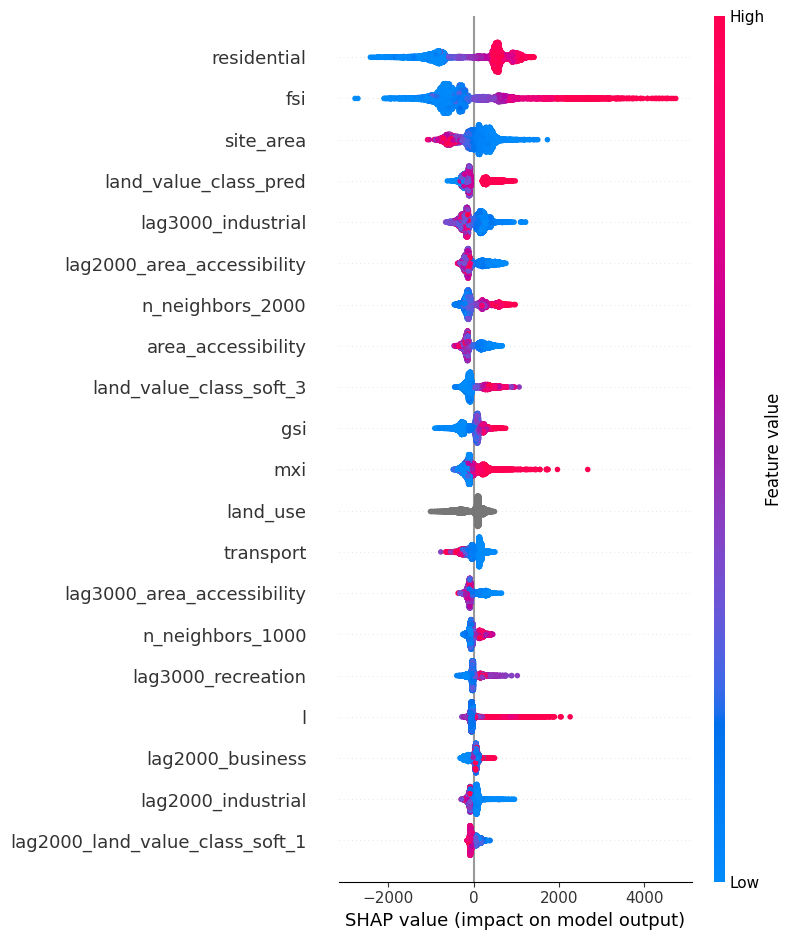

In [ ]:
# === SHAP: beeswarm + bar для текущей модели ===
import shap

from urbanomy.methods.land_value_modeling.training_utils import (
    prep_cat_inplace,
    build_radii_weights,
    add_lags_full_df,
    feature_names,
)

target_col = cfg.target_col

numeric_feats = [
    c for c in cfg.feature_cols
    if c not in cfg.cat_features and c != target_col and c in blocks_clean.columns
]

work_df = blocks_clean.copy()
prep_cat_inplace(work_df, cfg.cat_features)

weights_shap = build_radii_weights(work_df, cfg.radius_list)
data_lag_shap = add_lags_full_df(work_df, weights=weights_shap, numeric_cols=numeric_feats)

base_cols_for_model = list(dict.fromkeys(list(cfg.feature_cols) + list(cfg.cat_features)))
feats = feature_names(data_lag_shap, base_cols_for_model, target_col)

X_shap = data_lag_shap[feats]

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap)

# 1) Beeswarm
shap.summary_plot(shap_values, X_shap, feature_names=feats, show=True)



In [ ]:
# === Inference + метрики для текущей модели ===
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score, mean_absolute_error

from urbanomy.methods.land_value_modeling.training_utils import (
    prep_cat_inplace,
    build_radii_weights,
    add_lags_full_df,
    feature_names,
    to_original_scale,
    mape,
    wape,
    rmse,
)

target_col = cfg.target_col

# 1) Восстанавливаем тот же набор числовых фич, что использовался при обучении
numeric_feats = [
    c for c in cfg.feature_cols
    if c not in cfg.cat_features and c != target_col and c in blocks_clean.columns
]

# 2) Готовим данные и считаем лаги так же, как в run_training
work_df = blocks_clean.copy()
prep_cat_inplace(work_df, cfg.cat_features)

weights_inf = build_radii_weights(work_df, cfg.radius_list)
data_lag_inf = add_lags_full_df(work_df, weights=weights_inf, numeric_cols=numeric_feats)

base_cols_for_model = list(dict.fromkeys(list(cfg.feature_cols) + list(cfg.cat_features)))
feats = feature_names(data_lag_inf, base_cols_for_model, target_col)

# 3) Проверка фичей
missing_feats = [c for c in feats if c not in data_lag_inf.columns]
if missing_feats:
    raise ValueError(
        f"Не хватает фичей для модели ({len(missing_feats)}): "
        f"{missing_feats[:20]}{' ...' if len(missing_feats) > 20 else ''}"
    )

# 4) Предсказание
y_pred_raw = np.asarray(model.predict(data_lag_inf[feats])).reshape(-1)
y_pred = to_original_scale(y_pred_raw, target_col=target_col)

out_df = data_lag_inf.copy()
out_df["pred_raw"] = y_pred_raw
out_df[f"{target_col}_pred"] = y_pred

# 5) Метрики
if target_col in out_df.columns:
    y_true_raw = out_df[target_col].to_numpy()
    y_true = to_original_scale(y_true_raw, target_col=target_col)

    out_df[f"{target_col}_true"] = y_true

    mask = np.isfinite(y_true) & np.isfinite(y_pred) & (np.abs(y_true) > 0)

    out_df["error_pct"] = np.nan
    out_df.loc[mask, "error_pct"] = (
        np.abs(y_pred[mask] - y_true[mask]) / np.abs(y_true[mask]) * 100.0
    )

    mape_val = mape(y_true[mask], y_pred[mask])
    wape_val = wape(y_true[mask], y_pred[mask])
    mae_val = mean_absolute_error(y_true[mask], y_pred[mask])
    rmse_val = rmse(y_true[mask], y_pred[mask])
    r2_val = r2_score(y_true[mask], y_pred[mask])

    print(f"Rows used in metrics: {mask.sum()} / {len(mask)}")
    print(f"MAPE: {mape_val:.6f} ({mape_val*100:.2f}%)")
    print(f"WAPE: {wape_val:.6f} ({wape_val*100:.2f}%)")
    print(f"MAE:  {mae_val:.6f}")
    print(f"RMSE: {rmse_val:.6f}")
    print(f"R2:   {r2_val:.6f}")

    display(out_df[[target_col, f"{target_col}_pred", "error_pct"]].head(20))

    out_df_over_10 = out_df[out_df["error_pct"] > 10].copy()
else:
    print(f"Column '{target_col}' not found -> predictions only.")
    display(out_df[[f"{target_col}_pred"]].head(20))


Rows used in metrics: 6948 / 6948
MAPE: 0.155993 (15.60%)
WAPE: 0.171550 (17.16%)
MAE:  881.705992
RMSE: 2161.425117
R2:   0.856025


,land_value_per_sqm,land_value_per_sqm_pred,error_pct
0,942.386203,1030.150143,9.312948
1,1952.414484,1966.363687,0.714459
2,1507.223306,1509.092900,0.124042
3,2197.747147,2255.135303,2.611226
4,8603.688296,6892.154489,19.893024
5,1421.128598,1339.139000,5.769330
7,1160.558788,1221.338196,5.237081
8,3325.537139,3394.607568,2.076971
9,1627.563780,1792.791535,10.151845
10,631.882251,639.630343,1.226192


In [ ]:
stats_by_landuse = (
    out_df
    .groupby("land_use", dropna=False)
    .agg(
        n=("error_pct", "size"),
        mean_error_pct=("error_pct", "mean"),
        median_error_pct=("error_pct", "median"),
        max_error_pct=("error_pct", "max"),
    )
    .sort_values("mean_error_pct", ascending=False)
)

display(stats_by_landuse)

,n,mean_error_pct,median_error_pct,max_error_pct
land_use,,,,
RECREATION,1054,21.026599,8.667426,612.103898
BUSINESS,270,15.734633,7.138874,458.182637
RESIDENTIAL,4152,15.343019,8.336037,288.196000
TRANSPORT,806,14.282444,5.855037,307.655194
INDUSTRIAL,445,10.768648,4.431247,136.413734
AGRICULTURE,119,9.223782,3.583704,116.766439
SPECIAL,102,8.510995,4.110815,57.875662


In [ ]:
out_df_over_100 = out_df[out_df["error_pct"] > 100]
out_df_100 = out_df[out_df["error_pct"] <= 100]

stats_by_landuse = (
    out_df_over_100
    .groupby("land_use", dropna=False)
    .agg(
        n=("error_pct", "size"),
        mean_error_pct=("error_pct", "mean"),
        median_error_pct=("error_pct", "median"),
        max_error_pct=("error_pct", "max"),
    )
)

stats_by_landuse["share_of_all_plots_pct"] = (
    stats_by_landuse["n"] / len(out_df) * 100
)

stats_by_landuse = stats_by_landuse.sort_values("mean_error_pct", ascending=False)

display(stats_by_landuse)


,n,mean_error_pct,median_error_pct,max_error_pct,share_of_all_plots_pct
land_use,,,,,
BUSINESS,2,283.313633,283.313633,458.182637,0.028785
RECREATION,35,174.555930,140.680269,612.103898,0.503742
TRANSPORT,10,156.340686,129.245228,307.655194,0.143926
RESIDENTIAL,25,142.504384,131.927413,288.196000,0.359816
INDUSTRIAL,1,136.413734,136.413734,136.413734,0.014393
AGRICULTURE,1,116.766439,116.766439,116.766439,0.014393


In [ ]:
# === Conformal interval по land_use ===
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

alpha = 0.10  # 90% PI
group_col = "land_use"
true_col = "land_value_per_sqm_true"
pred_col = "land_value_per_sqm_pred"

# 1) валидные строки
valid_mask = (
    np.isfinite(out_df[true_col].to_numpy()) &
    np.isfinite(out_df[pred_col].to_numpy()) &
    out_df[group_col].notna()
)
df_valid = out_df.loc[valid_mask].copy()

# 2) calibration / evaluation
idx_cal, idx_eval = train_test_split(
    df_valid.index, test_size=0.5, random_state=42, shuffle=True
)
cal_df = df_valid.loc[idx_cal].copy()
eval_df = df_valid.loc[idx_eval].copy()

# 3) глобальный q_hat (fallback)
abs_err_cal_all = np.abs(cal_df[pred_col] - cal_df[true_col]).to_numpy()
n_all = len(abs_err_cal_all)
k_all = int(np.ceil((n_all + 1) * (1 - alpha)))
k_all = min(max(k_all, 1), n_all)
q_hat_global = np.partition(abs_err_cal_all, k_all - 1)[k_all - 1]

# 4) q_hat по группам land_use
min_cal_size = 30  # если в группе мало точек, используем глобальный q_hat
qhat_by_group = {}

for g, gdf in cal_df.groupby(group_col):
    abs_err = np.abs(gdf[pred_col] - gdf[true_col]).to_numpy()
    n = len(abs_err)
    if n < min_cal_size:
        qhat_by_group[g] = q_hat_global
        continue
    k = int(np.ceil((n + 1) * (1 - alpha)))
    k = min(max(k, 1), n)
    qhat_by_group[g] = np.partition(abs_err, k - 1)[k - 1]

# 5) строим интервалы
q_series = out_df[group_col].map(qhat_by_group).fillna(q_hat_global)
out_df["q_hat_land_use"] = q_series

out_df["pi_lower"] = (out_df[pred_col] - out_df["q_hat_land_use"]).clip(lower=0)
out_df["pi_upper"] = out_df[pred_col] + out_df["q_hat_land_use"]

# 6) оценка покрытия на eval
eval_tmp = out_df.loc[idx_eval].copy()
covered_eval = (eval_tmp[true_col] >= eval_tmp["pi_lower"]) & (eval_tmp[true_col] <= eval_tmp["pi_upper"])

coverage_eval_total = covered_eval.mean() * 100
avg_width_eval_total = (eval_tmp["pi_upper"] - eval_tmp["pi_lower"]).mean()

print(f"Target coverage: {(1-alpha)*100:.1f}%")
print(f"Empirical coverage (eval, total): {coverage_eval_total:.2f}%")
print(f"Average interval width (eval, total): {avg_width_eval_total:.2f}")

# покрытие по land_use
coverage_by_landuse = (
    eval_tmp.assign(covered=covered_eval)
    .groupby(group_col)
    .agg(
        n=("covered", "size"),
        coverage_pct=("covered", lambda s: s.mean() * 100),
        avg_width=("pi_upper", lambda s: (s - eval_tmp.loc[s.index, "pi_lower"]).mean()),
        q_hat=("q_hat_land_use", "mean"),
    )
    .sort_values("coverage_pct")
)

display(coverage_by_landuse)
display(out_df[[group_col, true_col, pred_col, "pi_lower", "pi_upper", "q_hat_land_use"]].head(20))


Target coverage: 90.0%
Empirical coverage (eval, total): 89.58%
Average interval width (eval, total): 4410.33


,n,coverage_pct,avg_width,q_hat
land_use,,,,
INDUSTRIAL,234,85.897436,1658.508071,833.014416
TRANSPORT,394,88.832487,1474.669455,744.723906
RESIDENTIAL,2052,88.888889,5930.371410,3066.201960
BUSINESS,144,91.666667,4445.480420,2405.013362
SPECIAL,62,91.935484,910.736394,458.359032
RECREATION,524,92.938931,2758.638983,1471.348084
AGRICULTURE,64,95.312500,642.284293,323.356769


,land_use,land_value_per_sqm_true,land_value_per_sqm_pred,pi_lower,pi_upper,q_hat_land_use
0,AGRICULTURE,942.386203,1030.150143,706.793374,1353.506913,323.356769
1,RESIDENTIAL,1952.414484,1966.363687,0.000000,5032.565647,3066.201960
2,RESIDENTIAL,1507.223306,1509.092900,0.000000,4575.294860,3066.201960
3,RESIDENTIAL,2197.747147,2255.135303,0.000000,5321.337263,3066.201960
4,INDUSTRIAL,8603.688296,6892.154489,6059.140073,7725.168905,833.014416
5,AGRICULTURE,1421.128598,1339.139000,1015.782231,1662.495769,323.356769
7,RESIDENTIAL,1160.558788,1221.338196,0.000000,4287.540156,3066.201960
8,RESIDENTIAL,3325.537139,3394.607568,328.405608,6460.809528,3066.201960
9,RESIDENTIAL,1627.563780,1792.791535,0.000000,4858.993495,3066.201960
10,AGRICULTURE,631.882251,639.630343,316.273574,962.987113,323.356769


In [ ]:
# model_path = f"catboost_land_value_{'with_services' if use_services else 'no_services'}.cbm"
# model.save_model(model_path)
# print(model_path)

